# Credit Card Fraud Detection — EDA & Evaluation Setup

Dataset validation, class imbalance, exploratory analysis, and the evaluation framework used in later modeling stages.

## 1. Imports and Configuration

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

pd.set_option("display.max_columns", 35)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
sns.set_theme(style="whitegrid")

## 2. Load the Dataset

The notebook is under `notebooks/` and the dataset is under `data/`. The project-relative path keeps the notebook reproducible.

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "creditcard.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)

print(f"Dataset path: {DATA_PATH.resolve()}")
print(f"Shape: {df.shape}")

Dataset path: D:\3\JupyterProjects\ML Projects\fraud-detection\data\creditcard.csv
Shape: (284807, 31)


## 3. Dataset Validation

Check the dataset structure, data types, missing values, and duplicate rows before analysis.

In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print(f"\nMissing values: {df.isna().sum().sum():,}")
print(f"Duplicate rows: {df.duplicated().sum():,}")

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:


,dtype
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64



Missing values: 0
Duplicate rows: 1,081


In [4]:
display(df.head())
display(df.describe().T)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


,count,mean,std,min,25%,50%,75%,max
Time,284807.0000,94813.8596,47488.1460,0.0000,54201.5000,84692.0000,139320.5000,172792.0000
V1,284807.0000,0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549
V2,284807.0000,0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577
V3,284807.0000,-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826
V4,284807.0000,0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753
V5,284807.0000,0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017
V6,284807.0000,0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016
V7,284807.0000,-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895
V8,284807.0000,0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072
V9,284807.0000,-0.0000,1.0986,-13.4341,-0.6431,-0.0514,0.5971,15.5950


## 4. Target Distribution and Class Imbalance

Fraud is a rare class. Quantifying the imbalance is necessary because a model can achieve high accuracy while detecting very little fraud.

In [5]:
class_counts = df["Class"].value_counts().sort_index()
class_percentages = df["Class"].value_counts(normalize=True).sort_index() * 100

non_fraud_count = class_counts[0]
fraud_count = class_counts[1]
imbalance_ratio = non_fraud_count / fraud_count

print("Class distribution")
print(f"Non-Fraud (0): {non_fraud_count:,} ({class_percentages[0]:.4f}%)")
print(f"Fraud (1):     {fraud_count:,} ({class_percentages[1]:.4f}%)")
print(f"Imbalance ratio: approximately 1 fraud for every {imbalance_ratio:.0f} non-fraud transactions")

Class distribution
Non-Fraud (0): 284,315 (99.8273%)
Fraud (1):     492 (0.1727%)
Imbalance ratio: approximately 1 fraud for every 578 non-fraud transactions


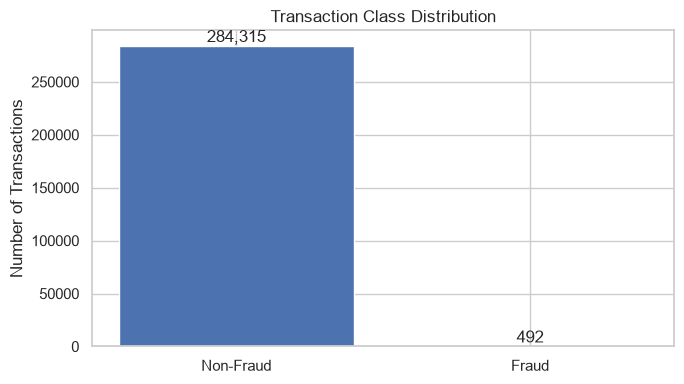

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["Non-Fraud", "Fraud"], class_counts.values)
ax.set_title("Transaction Class Distribution")
ax.set_ylabel("Number of Transactions")

for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{count:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

### Why accuracy is misleading

An all-negative classifier would achieve accuracy close to the non-fraud rate while detecting no fraudulent transactions. Accuracy is therefore not an appropriate primary metric for this problem.

In [7]:
y_true = df["Class"]
all_non_fraud_predictions = np.zeros(len(y_true), dtype=int)

tn, fp, fn, tp = confusion_matrix(y_true, all_non_fraud_predictions).ravel()
accuracy = (tn + tp) / len(y_true)

print(f"All-negative baseline accuracy: {accuracy:.4%}")
print(f"All-negative baseline recall:    {recall_score(y_true, all_non_fraud_predictions, zero_division=0):.4%}")
print(f"False negatives: {fn:,}")
print(f"True positives:  {tp:,}")

All-negative baseline accuracy: 99.8273%
All-negative baseline recall:    0.0000%
False negatives: 492
True positives:  0


## 5. Transaction Amount Analysis

Compare the distribution and summary statistics of `Amount` for fraudulent and legitimate transactions. The feature is highly skewed, which motivates robust scaling in Stage 2.

In [8]:
amount_stats = (
    df.groupby("Class")["Amount"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.99])
    .T
)

display(amount_stats)

print(f"Overall Amount skewness: {df['Amount'].skew():.4f}")
print(f"Non-fraud Amount skewness: {df.loc[df['Class'] == 0, 'Amount'].skew():.4f}")
print(f"Fraud Amount skewness: {df.loc[df['Class'] == 1, 'Amount'].skew():.4f}")

Class,0,1
count,284315.0000,492.0000
mean,88.2910,122.2113
std,250.1051,256.6833
min,0.0000,0.0000
25%,5.6500,1.0000
50%,22.0000,9.2500
75%,77.0500,105.8900
90%,202.7240,346.7460
99%,1016.9664,1357.4279
max,25691.1600,2125.8700


Overall Amount skewness: 16.9777
Non-fraud Amount skewness: 17.0031
Fraud Amount skewness: 3.7545


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20636\2735081846.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["Non-Fraud", "Fraud"])


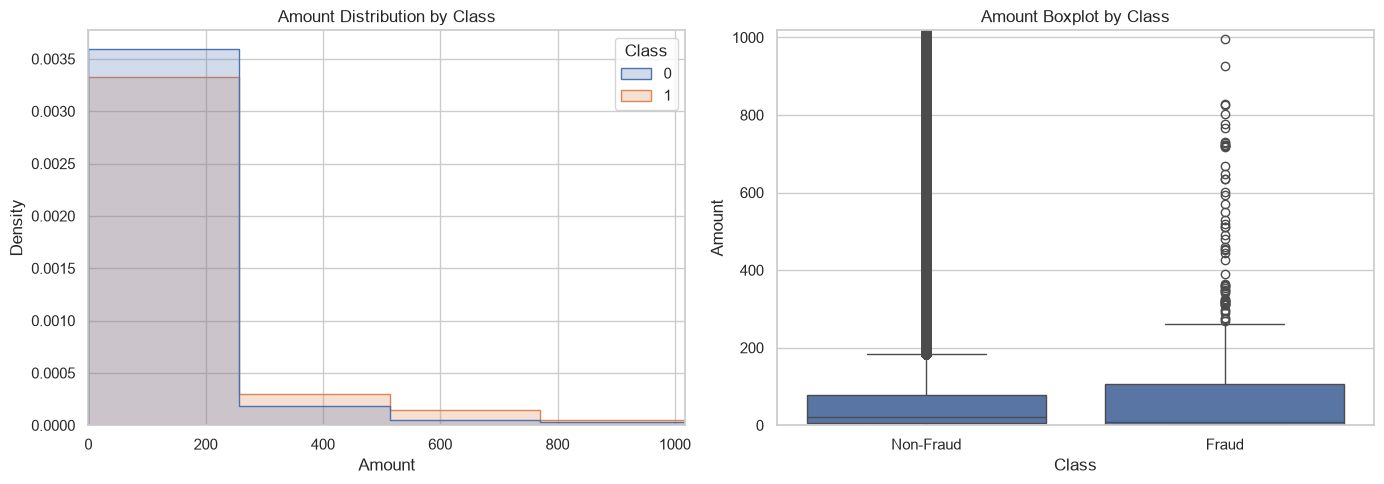

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="Amount", hue="Class", bins=100, stat="density",
             common_norm=False, element="step", ax=axes[0])
axes[0].set_title("Amount Distribution by Class")
axes[0].set_xlim(0, df["Amount"].quantile(0.99))

sns.boxplot(data=df, x="Class", y="Amount", ax=axes[1])
axes[1].set_title("Amount Boxplot by Class")
axes[1].set_ylim(0, df["Amount"].quantile(0.99))
axes[1].set_xticklabels(["Non-Fraud", "Fraud"])

plt.tight_layout()
plt.show()

The extreme values in `Amount` motivate the use of `RobustScaler` in Stage 2. No transformation is fitted on the full dataset here.

## 6. Transaction Time Analysis

`Time` records seconds elapsed since the first transaction. Comparing the class distributions can reveal temporal differences in fraud activity.

In [10]:
time_stats = (
    df.groupby("Class")["Time"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.99])
    .T
)

display(time_stats)

print(f"Overall Time skewness: {df['Time'].skew():.4f}")
print(f"Non-fraud Time skewness: {df.loc[df['Class'] == 0, 'Time'].skew():.4f}")
print(f"Fraud Time skewness: {df.loc[df['Class'] == 1, 'Time'].skew():.4f}")

Class,0,1
count,284315.0000,492.0000
mean,94838.2023,80746.8069
std,47484.0158,47835.3651
min,0.0000,406.0000
25%,54230.0000,41241.5000
50%,84711.0000,75568.5000
75%,139333.0000,128483.0000
90%,157652.6000,152029.6000
99%,170564.0000,167500.3600
max,172792.0000,170348.0000


Overall Time skewness: -0.0356
Non-fraud Time skewness: -0.0360
Fraud Time skewness: 0.2512


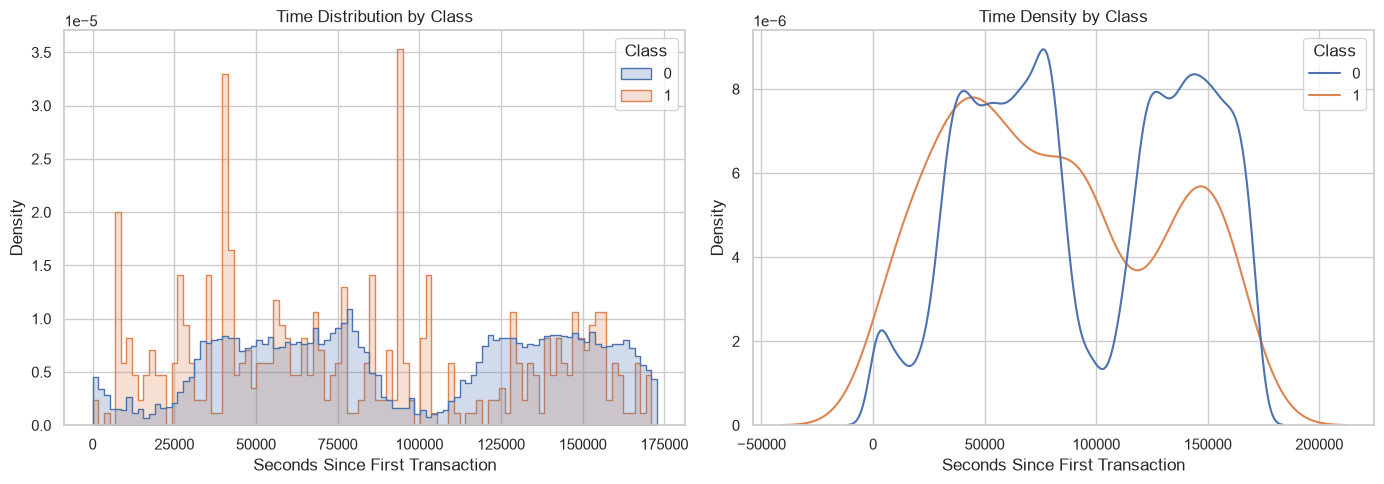

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="Time", hue="Class", bins=100, stat="density",
             common_norm=False, element="step", ax=axes[0])
axes[0].set_title("Time Distribution by Class")
axes[0].set_xlabel("Seconds Since First Transaction")

sns.kdeplot(data=df, x="Time", hue="Class", common_norm=False, ax=axes[1])
axes[1].set_title("Time Density by Class")
axes[1].set_xlabel("Seconds Since First Transaction")

plt.tight_layout()
plt.show()

## 7. PCA Feature Analysis (`V1`–`V28`)

`V1`–`V28` are anonymized principal components. Their original meanings are unavailable, so the analysis focuses on distributions and statistical relationships with the target.

In [12]:
pca_features = [f"V{i}" for i in range(1, 29)]

pca_stats = df.groupby("Class")[pca_features].mean().T
pca_stats.columns = ["Non-Fraud Mean", "Fraud Mean"]
pca_stats["Absolute Mean Difference"] = (
    pca_stats["Fraud Mean"] - pca_stats["Non-Fraud Mean"]
).abs()

display(pca_stats.sort_values("Absolute Mean Difference", ascending=False))

,Non-Fraud Mean,Fraud Mean,Absolute Mean Difference
V3,0.0122,-7.0333,7.0455
V14,0.0121,-6.9717,6.9838
V17,0.0115,-6.6658,6.6774
V12,0.0108,-6.2594,6.2702
V10,0.0098,-5.6769,5.6867
V7,0.0096,-5.5687,5.5784
V1,0.0083,-4.7719,4.7802
V4,-0.0079,4.5420,4.5499
V16,0.0072,-4.1399,4.1471
V11,-0.0066,3.8002,3.8067


In [13]:
correlations = df.corr(numeric_only=True)["Class"].drop("Class").sort_values()

print("Features with strongest negative correlation with Class:")
display(correlations.head(10).to_frame("correlation"))

print("Features with strongest positive correlation with Class:")
display(correlations.tail(10).sort_values(ascending=False).to_frame("correlation"))

Features with strongest negative correlation with Class:


,correlation
V17,-0.3265
V14,-0.3025
V12,-0.2606
V10,-0.2169
V16,-0.1965
V3,-0.1930
V7,-0.1873
V18,-0.1115
V1,-0.1013
V9,-0.0977


Features with strongest positive correlation with Class:


,correlation
V11,0.1549
V4,0.1334
V2,0.0913
V21,0.0404
V19,0.0348
V20,0.0201
V8,0.0199
V27,0.0176
V28,0.0095
Amount,0.0056


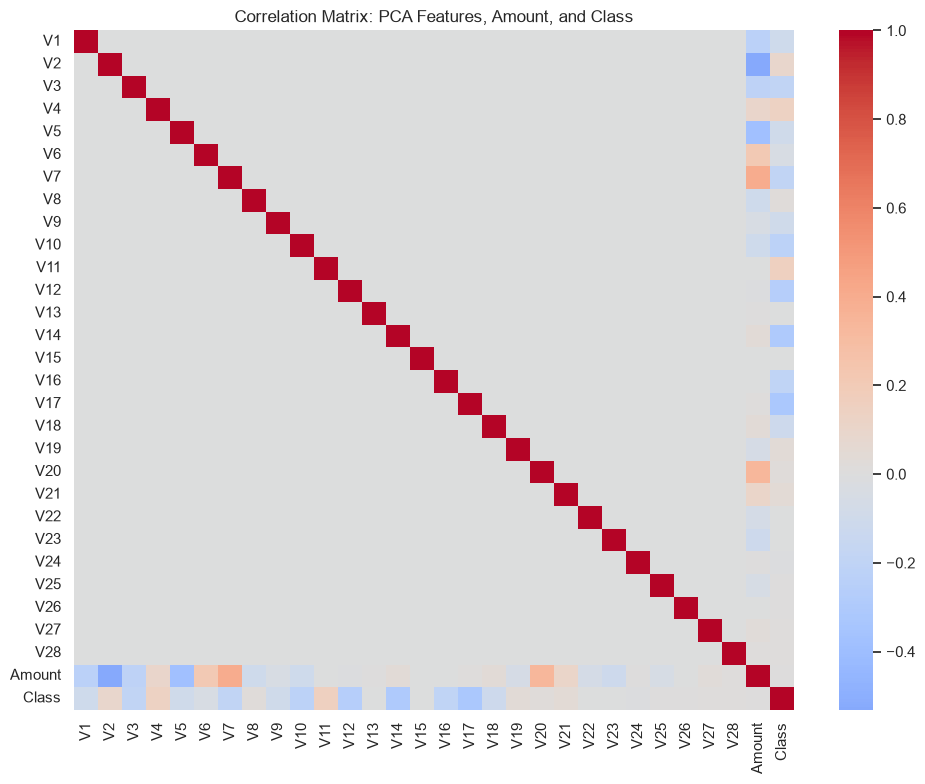

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[pca_features + ["Amount", "Class"]].corr(), cmap="coolwarm",
            center=0, xticklabels=True, yticklabels=True)
plt.title("Correlation Matrix: PCA Features, Amount, and Class")
plt.tight_layout()
plt.show()

## 8. Business-Aligned Evaluation Metrics

The modeling stages use:

- **PR-AUC / Average Precision** as the primary ranking metric
- **ROC-AUC** as a secondary ranking metric
- **Precision and Recall** at the operating threshold
- **F1** as a threshold-dependent summary
- **Financial cost** for asymmetric false-positive and false-negative consequences

The production threshold is selected later rather than assuming `0.5` is optimal.

### Cost-sensitive evaluation setup

The cost function is defined here for reuse. The threshold is optimized in Stage 4.

In [15]:
def calculate_fraud_cost(y_true, y_pred, false_positive_cost=1.0, false_negative_cost=10.0):
    """Calculate asymmetric classification cost for fraud detection."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    total_cost = (fp * false_positive_cost) + (fn * false_negative_cost)
    return {
        "false_positives": fp,
        "false_negatives": fn,
        "total_cost": total_cost,
    }

## 9. Stage 1 Evaluation Contract

Model evaluation will report PR-AUC, ROC-AUC, threshold-dependent precision/recall/F1, the confusion matrix, and the asymmetric financial cost.

## 10. Stage 1 Conclusions

- Fraud is highly imbalanced, so accuracy is not the primary metric.
- `Amount` is strongly skewed and contains extreme values.
- `Time` shows class-dependent distribution differences.
- `V1`–`V28` contain varying levels of association with the target and are retained for modeling.
- Later model comparison will prioritize PR-AUC and include ROC-AUC, precision, recall, and financial cost.
- No model or preprocessing transformation is fitted on the complete dataset in this notebook.